<img src="https://drive.google.com/uc?export=view&id=1WMR33zNEKj_zRZBqyLy4hf_EXhHOAfAk"
     alt="agripotential"
     width="250"
     height="250">
---------------------------------------------------------------------------
* **Author:** Mohammad El Sakka
* **Last Edited:** 9 DEC 2025
* **Colab Link:** https://colab.research.google.com/drive/1Ys_z7qBY1pa8iY7PMaLzDsTuiFaJDhHu
* **Version:** 1.0
* **Contact:** mohammad.el-sakka@outlook.com
* **Linkedin:** https://www.linkedin.com/in/mohammad-el-sakka/
* **GitHub:** https://github.com/MohammadElSakka/agripotential

## Citation
If you find this work helpful please cite the following:
```
@article{sakka2025agripotential,
title={AgriPotential: A Novel Multi-Spectral and Multi-Temporal Remote Sensing Dataset for Agricultural Potentials},
author={Sakka, Mohammad El and De Pourtales, Caroline and Chaari, Lotfi and Mothe, Josiane},
  journal={arXiv preprint arXiv:2506.11740},
  year={2025}
}
```
---------------------------------------------------------------------------

******** Notice ********

This notebook is in view only mode. We suggest to make your own copy that you can execute and edit.

To do so click on ```File > Save a copy in Drive``` or ```File > Download > Download .ipynb```


# Table of Contents
(Colab-style)


>[AgriPotential (v2)](#scrollTo=nwZJYNb379jY)

>>[Dataset structure](#scrollTo=7YdCq3SOBFcc)

>>[Accessing the data](#scrollTo=St3V3q6UCm48)

>>>[The metadata](#scrollTo=mWbj9R32FN2l)

>>>[Patch metadata](#scrollTo=KKT4Xfqocgx6)

>>>[Sentinel-2](#scrollTo=S6ySv5chA3Am)

>>>[Agricultural Potential Labels](#scrollTo=QolGydDaZfuc)

>>[Torch Dataset object](#scrollTo=Mz6bWkvLerYW)

>>[Using the AgriPotential Library](#scrollTo=TrtEUyNaevia)



# AgriPotential (v2)
Welcome to the AgriPotential tutorial which will show you how to easily access and manipulate the AgriPotential dataset.

To recall, the Agripotential dataset includes:
* As **inputs**: a Satellite Image Time Series (STIS) of 34 Sentinel-2 timeframes
* As **outputs**: 5 classes of agriculutural potential of 3 crops times, namely: very low, low, average, high, very high


Each Sentinel-2 image is made of 10 super-resolved bands at 5 m/px resolution, meaning that each pixel in the image measures 5 meters in realiy. A quick guide on Sentinel-2 images can be found at the [gisgeography](https://gisgeography.com/sentinel-2-bands-combinations/ ) website. Among the 13 original Sentinel-2 bands, the agripotential dataset has bands B2 B3 B4 B5 B6 B7 B8 B8A B11 B12.


## Dataset structure
The dataset is hosted on [HuggingFace](https://huggingface.co/datasets/m-sakka/agripotential/tree/main)

It contains:
* 34 TIF files corresponding to the 34 timeframes of Sentinel-2 images.
* 3 TIF files corresponding to the 3 crop types
* 3 CSV files with patch information
* 1 CSV file for metadata

The dataset has a zize of 200 GB. Files can be downloaded separately or together from HuggingFace. They can also be accessed **online** without the need of downloading them (if connection is too slow or if the server has a problem, online dataloading could be interrupted and raise an error)



## Accessing the data


### The metadata

The metadata file can be loaded using the standard csv library of Python but we prefer using pandas as it can load it from a remote server as well

Pandas can be install via
```
pip install pandas
```

The metadata contains the file names of Sentinel-2 data, ordered by ascending capture date. Notice how all file names start with T31TEJ. This is the name of the Sentinel-2 tile that covers the study area. A deeper explanation of Sentinel-2 tiles is presented on the [Copernicus Wiki website](https://sentiwiki.copernicus.eu/web/s2-products)

In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import pandas as pd

# root_path: The directory where the dataset is downloaded or hosted.
root_path = "https://huggingface.co/datasets/m-sakka/agripotential/resolve/main/"
path = root_path + "metadata.csv"
metadata = pd.read_csv(path)
metadata.head()

,filename,day,month,year
0,T31TEJ_2017_01_03.tif,3,1,2017
1,T31TEJ_2017_03_29.tif,29,3,2017
2,T31TEJ_2017_06_17.tif,17,6,2017
3,T31TEJ_2017_07_07.tif,7,7,2017
4,T31TEJ_2017_07_17.tif,17,7,2017


### Patch metadata
Given the voluminous aspect of the data, saving each patch as a separate file raises challenges in terms of storage and access. For this reason, only the coordinates of the patches are saved inside 3 csv files. Each csv file represents a subset of "train", "test", and "val".

The strucutre of the 3 csv files is identical. The columns are patch_id, the coordinates in row and col, the patch_size, and n_annoted that shows the number of annotated pixels in the patch

In [2]:
train_subset_path = root_path + "train.csv"

train_df = pd.read_csv(train_subset_path)
train_df.head()

,patch_id,row,col,patch_size,n_annotated
0,7296_14720,7296,14720,128,1724
1,5120_12672,5120,12672,128,4575
2,5184_12608,5184,12608,128,863
3,5184_12672,5184,12672,128,4077
4,5248_12608,5248,12608,128,1324


### Sentinel-2

Loading TIF files can be done via rasterio. Rasterio will create a pointer towards the data instead of loading it entirely and immediately in the memory. Another advantage of Rasterio is the possibility it offers to load the data from a remote server over http requests (like HuggingFace).

Rasterio can be installed by
```
pip install rasterio
```

As an example, we will display the first train patch during three different dates. With Rasterio, it is possible to load a Window of the bigger TIF image (very voluminous!).

In [3]:
from rasterio import rasterio
from rasterio.windows import Window

patch_row = train_df.iloc[0]["row"]
patch_col = train_df.iloc[0]["col"]
patch_size = train_df.iloc[0]["patch_size"]
patch_id = train_df.iloc[0]["patch_id"]

date1 = metadata.iloc[0]
date2 = metadata.iloc[15]
date3 = metadata.iloc[30]

print(date1)
print("--------------")
print(date2)
print("--------------")
print(date3)

filename    T31TEJ_2017_01_03.tif
day                             3
month                           1
year                         2017
Name: 0, dtype: object
--------------
filename    T31TEJ_2018_06_27.tif
day                            27
month                           6
year                         2018
Name: 15, dtype: object
--------------
filename    T31TEJ_2019_08_31.tif
day                            31
month                           8
year                         2019
Name: 30, dtype: object


In [4]:
date1_data = rasterio.open(root_path+date1["filename"])
date2_data = rasterio.open(root_path+date2["filename"])
date3_data = rasterio.open(root_path+date3["filename"])

date1_data.meta

{'driver': 'GTiff',
 'dtype': 'int16',
 'nodata': -10000.0,
 'width': 18770,
 'height': 15286,
 'count': 10,
 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 31N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",3],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32631"]]'),
 'transform': Affine(5.0, 0.0, 500140.0,
        0.0, -5.0, 4866810.0)}

A single Sentinel-2 timeframe contains 10 bands as previously stated. In a first time we will display some of them for illustration purpose, then we will reconstruct a color (RGB) image from the red, green, and blue bands (resp. B4, B3, B2)

In [5]:
date1_image = date1_data.read(window=Window(patch_col, patch_row, patch_size, patch_size))
date2_image = date2_data.read(window=Window(patch_col, patch_row, patch_size, patch_size))
date3_image = date3_data.read(window=Window(patch_col, patch_row, patch_size, patch_size))

date1_image.shape

(10, 128, 128)

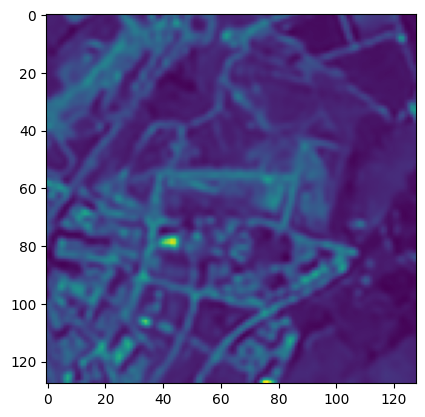

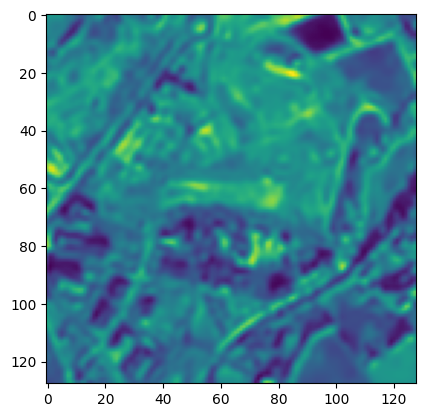

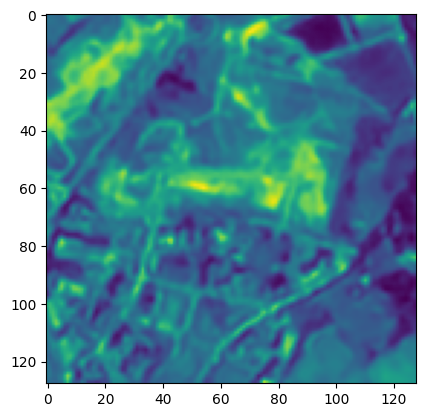

In [6]:
import matplotlib.pyplot as plt

plt.imshow(date1_image[0])
plt.show()
plt.imshow(date1_image[5])
plt.show()
plt.imshow(date1_image[9])
plt.show()

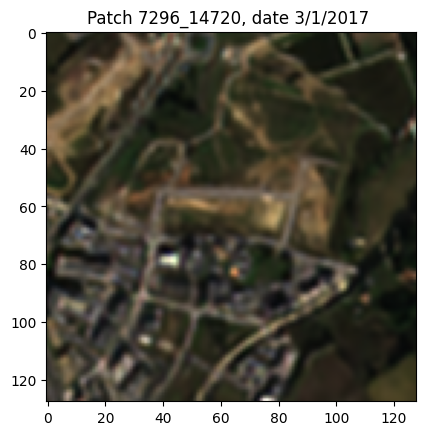

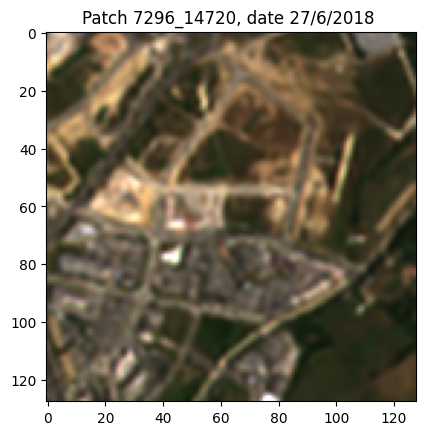

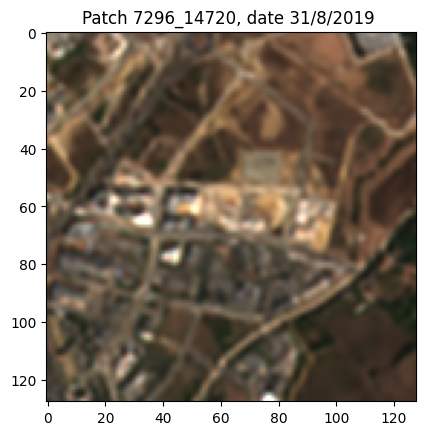

In [8]:
import numpy as np

def plot_rgb(red_band, green_band, blue_band, title):
  rgb = np.dstack((red_band, green_band, blue_band))

  # Sentinel-2 images provide reflectance in values between 0 and 10000.
  # Normalization
  rgb = rgb / 10000

  # Applying contrast enhancement for visualization
  rgb = np.clip(rgb, 0, 0.4)/ 0.4

  plt.imshow(rgb)
  plt.title(title)
  plt.show()

red1 = date1_image[2]
green1 = date1_image[1]
blue1 = date1_image[0]

red2 = date2_image[2]
green2 = date2_image[1]
blue2 = date2_image[0]

red3 = date3_image[2]
green3 = date3_image[1]
blue3 = date3_image[0]

plot_rgb(red1, green1, blue1, title=f"Patch {patch_id}, date {date1['day']}/{date1['month']}/{date1['year']} ")
plot_rgb(red2, green2, blue2, title=f"Patch {patch_id}, date {date2['day']}/{date2['month']}/{date2['year']} ")
plot_rgb(red3, green3, blue3, title=f"Patch {patch_id}, date {date3['day']}/{date3['month']}/{date3['year']} ")

### Agricultural Potential Labels
Each crop type has a corresponding TIF file for its labels. Those TIF files are aligned with the Sentinel-2 images. Therefore, loading labels is similar to loading Sentinel-2 images in our dataset.

We will work with the "viticulture" crop type for this example.

In [9]:
viticulture_label_path = root_path + "viticulture.tif"
viticulture_label_data = rasterio.open(viticulture_label_path)
viticulture_label_data.meta

{'driver': 'GTiff',
 'dtype': 'uint8',
 'nodata': 0.0,
 'width': 18770,
 'height': 15286,
 'count': 1,
 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 31N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",3],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32631"]]'),
 'transform': Affine(5.0, 0.0, 500140.0,
        0.0, -5.0, 4866810.0)}

In [10]:
viticulture_sample = viticulture_label_data.read(window=Window(patch_col, patch_row, patch_size, patch_size))
print(viticulture_sample.shape)
print(np.unique(viticulture_sample))

(1, 128, 128)
[0 2 3]


As you can see, some label pixels are set to 0. Those are pixels that are unlabelled and should not affect training. Otherwise, labelled pixels have a range of [1, 5], respectively corresponding to: "very low", "low", "average", "high", "very high"

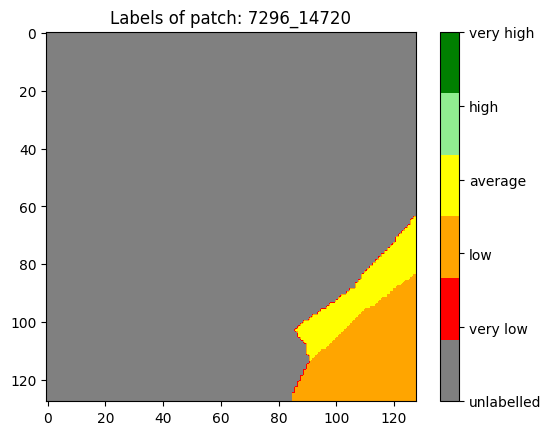

In [11]:
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

colors = [
    "gray",
    "red",
    "orange",
    "yellow",
    "#90EE90",  # Hex code for light green
    "green"
]

cmap = LinearSegmentedColormap.from_list(
    "Custom_GrayRedGreen",
    colors,
    N=6
)

plt.imshow(viticulture_sample[0], vmin=0, vmax=5, cmap=cmap)
cbar = plt.colorbar(ticks=[0, 1, 2, 3, 4, 5])
cbar.set_ticklabels(["unlabelled", "very low", "low", "average", "high", "very high"])
plt.title("Labels of patch: "+patch_id)
plt.show()

## Torch Dataset object

For illustration, we provide a torch Dataset object


In [3]:
import numpy as np
import os
import pandas as pd
import rasterio
from rasterio.windows import Window
from typing import Tuple, Optional, Literal


ROOT_URL = "https://huggingface.co/datasets/m-sakka/agripotential/resolve/main/"


class PotentialDataset:
    def __init__(
        self,
        label_name: Literal["viticulture", "market", "field"],
        mode: Literal["train", "val", "test"],
        data_path: Optional[str] = None,
    ):
        if data_path:
            self.data_path = data_path
        else:
            self.data_path = ROOT_URL

        self.metadata_path = os.path.join(self.data_path, "metadata.csv")
        self.patch_csv_path = os.path.join(self.data_path, f"{mode}.csv")
        self.label_path = os.path.join(self.data_path, f"{label_name}.tif")

        self.sentinel2_paths: list[str] = []
        self.patches: pd.DataFrame = pd.DataFrame()
        self._setup()

    def _setup(self):
        metadata_df = pd.read_csv(self.metadata_path)
        self.sentinel2_paths = [
            os.path.join(self.data_path, f) for f in metadata_df["filename"]
        ]
        self.patches = pd.read_csv(self.patch_csv_path)

    def __len__(self) -> int:
        return len(self.patches)

    def __iter__(self):
        for i in range(len(self)):
            yield self[i]

    def __getitem__(self, idx) -> Tuple[np.ndarray, np.ndarray, str]:
        patch_meta = self.patches.iloc[idx]
        row, col, patch_size, patch_id = (
            patch_meta["row"],
            patch_meta["col"],
            patch_meta["patch_size"],
            patch_meta["patch_id"],
        )
        window = Window(col, row, patch_size, patch_size)

        data = np.empty((34, 10, patch_size, patch_size), dtype=np.float32)
        for i, fp in enumerate(self.sentinel2_paths):
            with rasterio.open(fp) as src:
                data[i] = src.read(window=window)

        with rasterio.open(self.label_path) as src:
            label = src.read(window=window)[0].astype(np.uint8)

        return data, label, patch_id

In [41]:
from torch.utils.data import DataLoader

dataset = PotentialDataset("viticulture", "val", root_path)
dataloader = DataLoader(dataset, batch_size=4, shuffle=False)
iterator = iter(dataloader)

print(root_path)


https://huggingface.co/datasets/m-sakka/agripotential/resolve/main/


In [42]:
data_batch, label_batch, patch_id_batch = next(iterator)
print(data_batch.shape)
print(label_batch.shape)
print(patch_id_batch)

torch.Size([4, 34, 10, 128, 128])
torch.Size([4, 128, 128])
('9472_2048', '9472_2112', '9472_2176', '9536_2048')


## Using the AgriPotential Library
You can achieve the same behavior with the AgriPotential library that contains utilities related to the AgriPotential dataset

In [18]:
# If a pip error (below) occurs, it is normal in Colab and will not affect the tutorial
# ----
# ERROR: pip's dependency resolver does not currently take into account all the packages that are installed.
# This behaviour is the source of the following dependency conflicts.
# google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
# ----
%pip install git+https://github.com/MohammadElSakka/agripotential.git

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
  Cloning https://github.com/MohammadElSakka/agripotential.git to /tmp/pip-req-build-jpujpfdt
  Running command git clone --filter=blob:none --quiet https://github.com/MohammadElSakka/agripotential.git /tmp/pip-req-build-jpujpfdt
  Resolved https://github.com/MohammadElSakka/agripotential.git to commit b5c8ae4a8ac2afe734792d0d1f0ab8b9ec94d84f
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Obtaining dependency information for pandas==2.3.3 from https://files.pythonhosted.org/packages/40/a8/4dac1f8f8235e5d25b9955d02ff6f29396191d4e665d71122c3722ca83c5/pandas-2.3.3-cp310-cp310-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 2.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [43]:
# should be ok if no error message
import agripotential

In [23]:
from agripotential.dataset import download_dataset

#   dest_dir (str): The destination directory where the dataset will be downloaded.
#   download_images (bool): Whether to download the Sentinel-2 image files. Defaults to True.
#                            can take some time
data_path = "./data/"
download_dataset(data_path, download_images=True)


[1/3] Downloading https://huggingface.co/datasets/m-sakka/agripotential/resolve/main/train.csv... Done.
[2/3] Downloading https://huggingface.co/datasets/m-sakka/agripotential/resolve/main/val.csv... Done.
[3/3] Downloading https://huggingface.co/datasets/m-sakka/agripotential/resolve/main/metadata.csv... Done.
[1/3] Downloading https://huggingface.co/datasets/m-sakka/agripotential/resolve/main/viticulture.tif... Done.
[2/3] Downloading https://huggingface.co/datasets/m-sakka/agripotential/resolve/main/market.tif... Done.
[3/3] Downloading https://huggingface.co/datasets/m-sakka/agripotential/resolve/main/field.tif... Done.
Parameter 'download_images' is True so downloading satellite images (might take a while).
[1/34] Downloading https://huggingface.co/datasets/m-sakka/agripotential/resolve/main/T31TEJ_2017_01_03.tif ... Done.
[2/34] Downloading https://huggingface.co/datasets/m-sakka/agripotential/resolve/main/T31TEJ_2017_03_29.tif ... Done.
[3/34] Downloading https://huggingface.co/

True

In [21]:
from agripotential.dataset import PotentialDataset
# This is a vanilla python dataset object that is compatible with PyTorch DataLoader

# if data_path is None, the class will retrieve the dataset online,
# otherwise it expects a directory with all the dataset material
# label_name is one of the three crop types: viticulture, market, field
# subset is one of train test val
dataset = PotentialDataset(data_path=None, label_name="viticulture", mode="val")

If the following cell crashes it is more likely an issue with the environment or the network on Colab.

Expected output:
```
torch.Size([4, 34, 10, 128, 128])
torch.Size([4, 128, 128])
('9472_2048', '9472_2112', '9472_2176', '9536_2048')
```

In [22]:
from torch.utils.data import DataLoader

dataloader = DataLoader(dataset, batch_size=4, shuffle=False)
iterator = iter(dataloader)

data_batch, label_batch, patch_id_batch = next(iterator)
print(data_batch.shape)
print(label_batch.shape)
print(patch_id_batch)

torch.Size([4, 34, 10, 128, 128])
torch.Size([4, 128, 128])
('9472_2048', '9472_2112', '9472_2176', '9536_2048')


In [29]:
%pip install cupy-cuda12x

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
import torch
import os
import numpy as np
from tqdm import tqdm


data_path = 'data/agripotential' 
dataset = PotentialDataset("viticulture", "train", data_path)
save_dir = "data/precomputed_tensors/train/"
os.makedirs(save_dir, exist_ok=True)

CHUNK_SIZE = 256
data_chunk, label_chunk, id_chunk = [], [], []
chunk_index = 0

print(f"Extracting dataset into chunks of {CHUNK_SIZE}...")

for i in tqdm(range(len(dataset))):
    data, label, patch_id = dataset[i]
    
    # Append to our running chunk list
    data_chunk.append(torch.tensor(data, dtype=torch.float32))
    label_chunk.append(torch.tensor(label, dtype=torch.long))
    id_chunk.append(patch_id)
    
    # Save the chunk if it is full OR if it is the very last patch in the dataset
    if len(data_chunk) == CHUNK_SIZE or i == len(dataset) - 1:
        torch.save({
            'data': torch.stack(data_chunk),     # Shape becomes (256, 34, 10, 128, 128)
            'label': torch.stack(label_chunk),   # Shape becomes (256,)
            'patch_ids': id_chunk
        }, os.path.join(save_dir, f"chunk_{chunk_index:04d}.pt"))
        
        # Reset lists for the next chunk
        data_chunk, label_chunk, id_chunk = [], [], []
        chunk_index += 1

Extracting dataset into chunks of 256...


100%|██████████| 6329/6329 [19:36<00:00,  5.38it/s]  


In [2]:
import os
import torch
import random
from torch.utils.data import IterableDataset, DataLoader, get_worker_info

class StreamingChunkDataset(IterableDataset):
    def __init__(self, chunk_dir, shuffle=True, seed=42):
        super().__init__()
        self.chunk_dir = chunk_dir
        # Sort files to ensure all workers start with the exact same baseline list
        self.chunk_files = sorted([f for f in os.listdir(chunk_dir) if f.endswith('.pt')])
        self.shuffle = shuffle
        self.seed = seed

    def __iter__(self):
        # --- THE CRITICAL FIX: WORKER SHARDING ---
        worker_info = get_worker_info()
        if worker_info is None:
            worker_id = 0
            num_workers = 1
        else:
            worker_id = worker_info.id
            num_workers = worker_info.num_workers
            
        # Slice the file list so each worker gets unique files
        # e.g., Worker 0 gets files [0, 4, 8], Worker 1 gets [1, 5, 9]
        worker_files = self.chunk_files[worker_id::num_workers]

        # Set up a localized random generator to prevent identical worker shuffles
        rng = random.Random(self.seed + worker_id)
        # -----------------------------------------

        # 1. Shuffle the order in which we load the massive chunks
        if self.shuffle:
            rng.shuffle(worker_files)
            
        # 2. Process one chunk at a time
        for chunk_file in worker_files:
            file_path = os.path.join(self.chunk_dir, chunk_file)
            
            # memory-mapped load leaves the heavy array on disk until yielded
            payload = torch.load(file_path, weights_only=True, mmap=True)
            chunk_data = payload['data']
            chunk_labels = payload['label']
            
            num_patches_in_chunk = chunk_data.size(0)
            
            # 3. Create an index array to shuffle patches WITHIN the chunk
            indices = list(range(num_patches_in_chunk))
            if self.shuffle:
                rng.shuffle(indices)
                
            # 4. Yield individual patches one-by-one to the DataLoader
            for idx in indices:
                yield chunk_data[idx], chunk_labels[idx]

# --- The Ultimate DataLoader Setup ---

# You can now save huge files to disk (e.g., 1000 patches per .pt file)
dataset = StreamingChunkDataset("data/precomputed_tensors/train")

# And you retain total control over your batch size!
dataloader = DataLoader(
    dataset,
    batch_size=128,     # You can change this anytime without re-extracting data!
    num_workers=4,      # 4 CPU workers will stream different chunks in parallel
    pin_memory=True
)

for data, label in dataloader:
    # Data shape will be perfectly [128, 34, 10, 128, 128]
    print("Done")
    break

/usr/local/lib/python3.10/dist-packages/torch/_utils.py:830: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
/usr/local/lib/python3.10/dist-packages/torch/_utils.py:830: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
/usr/local/lib/python3.10/dist-packages/torch/_utils.py:830: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you

Done


Starting GPU-accelerated EDA...


0it [00:00, ?it/s]/usr/local/lib/python3.10/dist-packages/torch/_utils.py:830: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
/usr/local/lib/python3.10/dist-packages/torch/_utils.py:830: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
/usr/local/lib/python3.10/dist-packages/torch/_utils.py:830: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should 

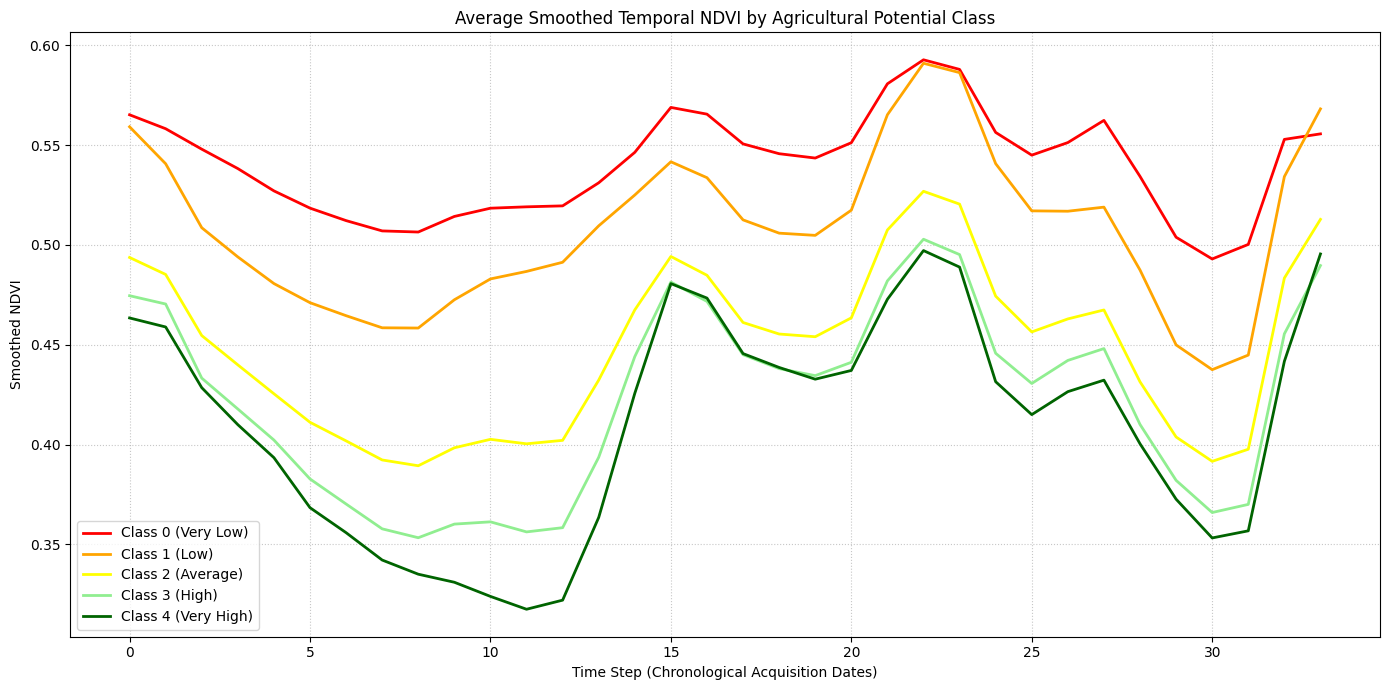

In [3]:
import torch
import cupy as cp
import numpy as np
import matplotlib.pyplot as plt
from cupyx.scipy.ndimage import median_filter
from tqdm import tqdm

from agripotential.dataset import PotentialDataset
from torch.utils.data import DataLoader


# data_path = 'data/agripotential' 
dataset = StreamingChunkDataset("data/precomputed_tensors/train")
dataloader = DataLoader(dataset, batch_size=128, shuffle=False, num_workers=4, pin_memory=True)

# Sentinel-2 Band Indices
RED_IDX = 2
NIR_IDX = 6

# We will store the average smoothed NDVI for EDA visualization
class_ndvis = {0: [], 1: [], 2: [], 3: [], 4: []}

print("Starting GPU-accelerated EDA...")

# 2. Iterate through batches
for batch_idx, (images, labels) in tqdm(enumerate(dataloader)):
    # Extract just Red and NIR from the 10 spectral channels
    red_band = images[:, :, RED_IDX, :, :]
    nir_band = images[:, :, NIR_IDX, :, :]
    
    red_band = red_band.cuda()
    nir_band = nir_band.cuda()
    labels = labels.cuda()
    
    # Move the heavy arrays directly to the GPU using CuPy
    # (Converting PyTorch tensors to CuPy arrays via DLPack is zero-copy and extremely fast)
    red_gpu = cp.from_dlpack(red_band.detach())
    nir_gpu = cp.from_dlpack(nir_band.detach())
    labels_gpu = cp.from_dlpack(labels.detach())
    
    # 3. Calculate NDVI on the GPU for the entire batch at once
    # Shape becomes (batch_size, timeframes, 128, 128)
    ndvi_gpu = (nir_gpu - red_gpu) / (nir_gpu + red_gpu + 1e-8)
    
    # 4. Temporal Smoothing on GPU (Median Filter along the time axis)
    # Filter size (1, 3, 1, 1) -> smoothing across timeframes only
    smoothed_ndvi_gpu = median_filter(ndvi_gpu, size=(1, 3, 1, 1))
    
    # 5. Group by Class for the EDA
    # Since labels are pixel-level, we can extract the temporal curve for every pixel based on its class
    for c in range(5):
        # Create a mask for pixels belonging to class 'c'
        class_mask = (labels_gpu == c)
        
        # If the batch contains this class
        if cp.any(class_mask):
            # Extract the temporal curves for all pixels of this class
            # We expand the mask across the time dimension
            ndvi_transposed = smoothed_ndvi_gpu.transpose(0, 2, 3, 1)
            
            # Apply the 3D spatial mask (Batch, Height, Width) directly.
            # CuPy instantly returns a 2D array of shape (num_valid_pixels, 34)
            class_pixels = ndvi_transposed[class_mask] 
            
            # Now average across the pixels (axis=0) to get the true temporal curve (shape: 34,)
            mean_curve = cp.nanmean(class_pixels, axis=0)
            
            class_ndvis[c].append(mean_curve.get())

# 6. Aggregate and Plot the Results
plt.figure(figsize=(14, 7))
colors = ['red', 'orange', 'yellow', 'lightgreen', 'darkgreen']
labels_text = ['Very Low', 'Low', 'Average', 'High', 'Very High']

for c in range(5):
    if len(class_ndvis[c]) > 0:
        # Average the curves across all batches
        final_curve = np.nanmean(np.array(class_ndvis[c]), axis=0)
        plt.plot(final_curve, color=colors[c], label=f'Class {c} ({labels_text[c]})', linewidth=2)

plt.title('Average Smoothed Temporal NDVI by Agricultural Potential Class')
plt.xlabel('Time Step (Chronological Acquisition Dates)')
plt.ylabel('Smoothed NDVI')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()